In [69]:
# Run from the repository root so dataset/ and saved_models/ resolve correctly
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Prevents Intel OpenMP and PyTorch OpenMP DLL collision on Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
print("OpenMP environment variables set")

OpenMP environment variables set


In [70]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import openpyxl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully")


All libraries imported successfully


In [71]:
# Detect CUDA-capable GPU and set the global compute device for PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Compute device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"VRAM: {mem_gb:.2f} GB")
else:
    print("No CUDA GPU detected, falling back to CPU")

Compute device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
VRAM: 23.89 GB


In [72]:
# Load Excel file with data_only=True so cached formula values are read instead of formula strings
DATASET_PATH = os.path.join('dataset', 'Landfilled Waste Composition Dataset.xlsx')

wb = openpyxl.load_workbook(DATASET_PATH, data_only=True)
ws = wb['Dataset']

headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
rows = [row for row in ws.iter_rows(min_row=2, values_only=True)]

df_raw = pd.DataFrame(rows, columns=headers)
df_raw = df_raw.loc[:, df_raw.columns.notna()]
df_raw.columns = df_raw.columns.str.strip()

print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Raw shape: (127033, 19)


,Facility Name,State,Facility Identification Number,State-Designated Facility Type,ORD-Designated Facility Type,Reporting Time Period,Calendar or Fiscal,Year,Original Waste Description,ORD-Designated Waste Stream,Waste Mass (short tons),Disposal Time Period,Transcribed by,Date Transcribed,Verified by,Date Verified,Transcription notes,Data Source Title,Date or Year Published
0,State of Alabama,AL,N/A,CDD Landfill,CDLF,Annual,Fiscal,2017,CD in-state,CDD,1236722.64,Oct 1-Sep 30,SM,2024-01-02 00:00:00,None,NaT,None,None,None
1,State of Alabama,AL,N/A,CDD Landfill,CDLF,Annual,Fiscal,2017,CD Out of state,CDD,1225936.09,Oct 1-Sep 30,SM,2024-01-02 00:00:00,None,NaT,None,None,None
2,State of Alabama,AL,N/A,CDD Landfill,CDLF,Annual,Fiscal,2018,CD in-state,CDD,1353468,Oct 1-Sep 30,SM,2024-01-02 00:00:00,None,NaT,None,None,None


In [73]:
print("Columns:", list(df_raw.columns))
print()
print("Dtypes:")
print(df_raw.dtypes)
print()
print("Null counts:")
print(df_raw.isnull().sum())
print()
year_numeric = pd.to_numeric(df_raw['Year'], errors='coerce')
print("Year range:", year_numeric.min(), "-", year_numeric.max())
print("Unique states:", df_raw['State'].nunique())
print()
print("Top waste streams:")
print(df_raw['ORD-Designated Waste Stream'].value_counts().head(12))


Columns: ['Facility Name', 'State', 'Facility Identification Number', 'State-Designated Facility Type', 'ORD-Designated Facility Type', 'Reporting Time Period', 'Calendar or Fiscal', 'Year', 'Original Waste Description', 'ORD-Designated Waste Stream', 'Waste Mass (short tons)', 'Disposal Time Period', 'Transcribed by', 'Date Transcribed', 'Verified by', 'Date Verified', 'Transcription notes', 'Data Source Title', 'Date or Year Published']

Dtypes:
Facility Name                             object
State                                     object
Facility Identification Number            object
State-Designated Facility Type            object
ORD-Designated Facility Type              object
Reporting Time Period                     object
Calendar or Fiscal                        object
Year                                      object
Original Waste Description                object
ORD-Designated Waste Stream               object
Waste Mass (short tons)                   object
Disposal 

In [74]:
# Drop formula strings left by XLOOKUP, coerce types, remove null targets and non-positive masses
df = df_raw.copy()

for col in ['ORD-Designated Facility Type', 'ORD-Designated Waste Stream']:
    if col in df.columns:
        mask = df[col].astype(str).str.startswith('=')
        df = df[~mask]

df['Waste Mass (short tons)'] = pd.to_numeric(df['Waste Mass (short tons)'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df = df.dropna(subset=['Waste Mass (short tons)', 'Year', 'State'])
df['Year'] = df['Year'].astype(int)
df = df[df['Waste Mass (short tons)'] > 0].reset_index(drop=True)

print(f"Clean dataset: {len(df):,} rows")
print(df[['State', 'Year', 'ORD-Designated Waste Stream', 'Waste Mass (short tons)']].describe())

Clean dataset: 115,940 rows
                Year  Waste Mass (short tons)
count  115940.000000             1.159400e+05
mean     2008.392427             6.699092e+04
std         9.598079             4.438510e+05
min      1938.000000             2.000000e-02
25%      2001.000000             3.517000e+02
50%      2011.000000             5.270400e+03
75%      2017.000000             3.518468e+04
max      2023.000000             2.803452e+07


In [75]:
# Select modeling columns and label-encode all categorical variables
CAT_COLS = ['State', 'ORD-Designated Facility Type', 'ORD-Designated Waste Stream', 'Calendar or Fiscal']
KEEP = CAT_COLS + ['Year', 'Waste Mass (short tons)']

df_model = df[KEEP].copy()
for col in CAT_COLS:
    df_model[col] = df_model[col].fillna('Unknown').astype(str)

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    encoders[col] = le

print("Encoding complete. Sample:")
df_model.head(3)

Encoding complete. Sample:


,State,ORD-Designated Facility Type,ORD-Designated Waste Stream,Calendar or Fiscal,Year,Waste Mass (short tons),State_enc,ORD-Designated Facility Type_enc,ORD-Designated Waste Stream_enc,Calendar or Fiscal_enc
0,AL,CDLF,CDD,Fiscal,2017,1236722.64,0,1,2,1
1,AL,CDLF,CDD,Fiscal,2017,1225936.09,0,1,2,1
2,AL,CDLF,CDD,Fiscal,2018,1353468.00,0,1,2,1


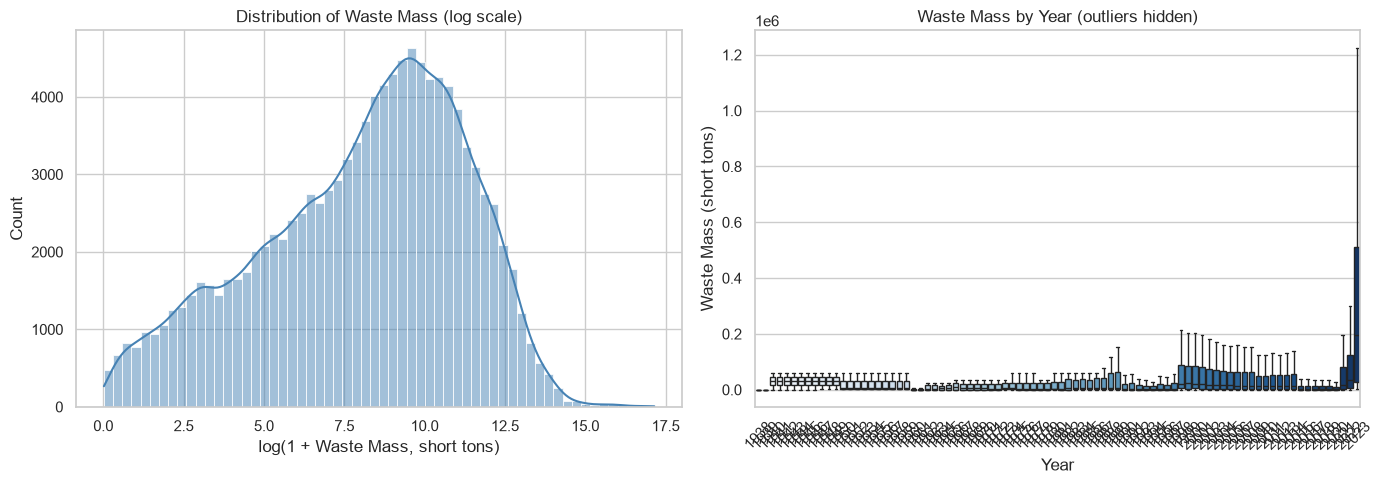

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_mass = np.log1p(df['Waste Mass (short tons)'])
sns.histplot(log_mass, bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Waste Mass (log scale)')
axes[0].set_xlabel('log(1 + Waste Mass, short tons)')

sns.boxplot(data=df, x='Year', y='Waste Mass (short tons)',
            showfliers=False, ax=axes[1], palette='Blues')
axes[1].set_title('Waste Mass by Year (outliers hidden)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


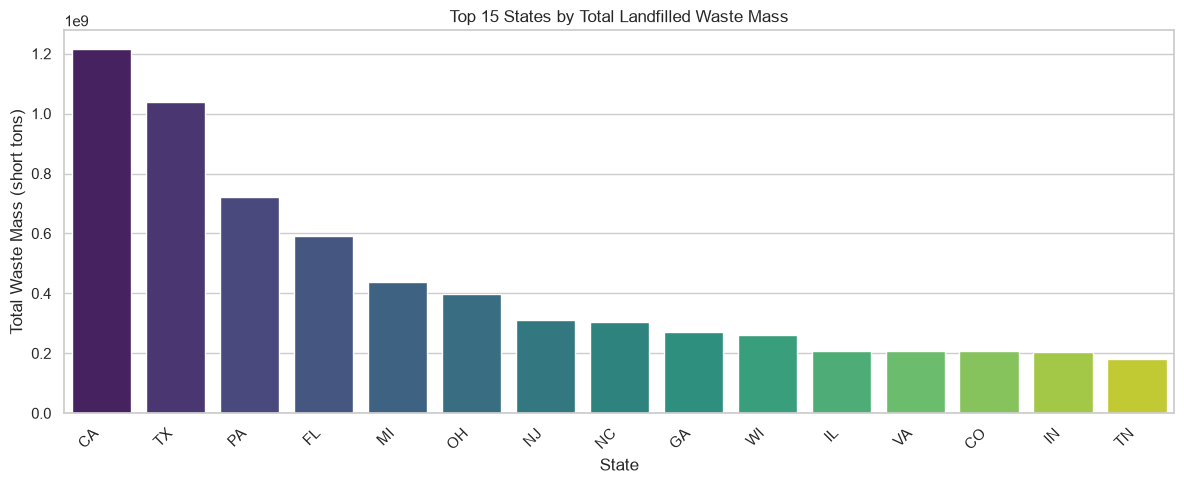

In [77]:
top_states = (df.groupby('State')['Waste Mass (short tons)']
              .sum().nlargest(15).reset_index())

plt.figure(figsize=(12, 5))
sns.barplot(data=top_states, x='State', y='Waste Mass (short tons)', palette='viridis')
plt.title('Top 15 States by Total Landfilled Waste Mass')
plt.xlabel('State')
plt.ylabel('Total Waste Mass (short tons)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


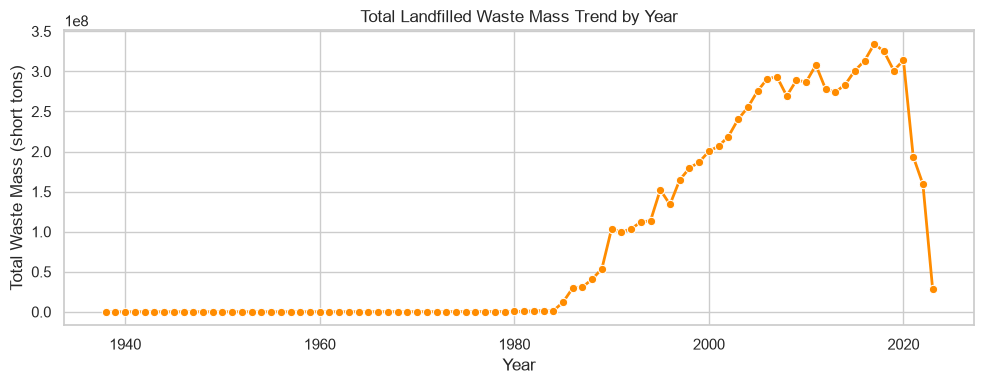

In [78]:
yearly = (df.groupby('Year')['Waste Mass (short tons)']
          .sum().reset_index())

plt.figure(figsize=(10, 4))
sns.lineplot(data=yearly, x='Year', y='Waste Mass (short tons)',
             marker='o', color='darkorange', linewidth=2)
plt.title('Total Landfilled Waste Mass Trend by Year')
plt.xlabel('Year')
plt.ylabel('Total Waste Mass (short tons)')
plt.tight_layout()
plt.show()


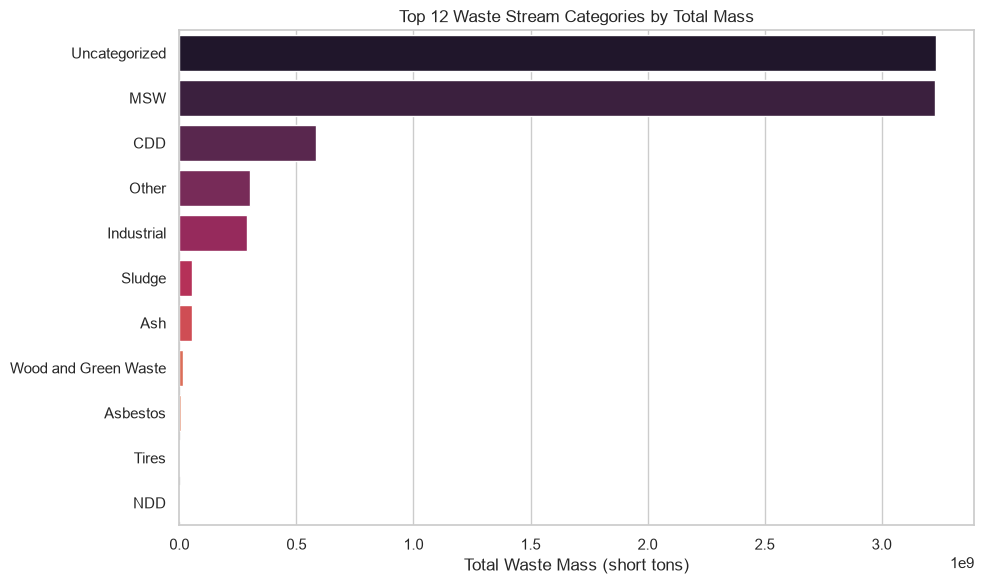

In [79]:
top_streams = (df.groupby('ORD-Designated Waste Stream')['Waste Mass (short tons)']
               .sum().nlargest(12).reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=top_streams, y='ORD-Designated Waste Stream',
            x='Waste Mass (short tons)', palette='rocket')
plt.title('Top 12 Waste Stream Categories by Total Mass')
plt.xlabel('Total Waste Mass (short tons)')
plt.ylabel('')
plt.tight_layout()
plt.show()


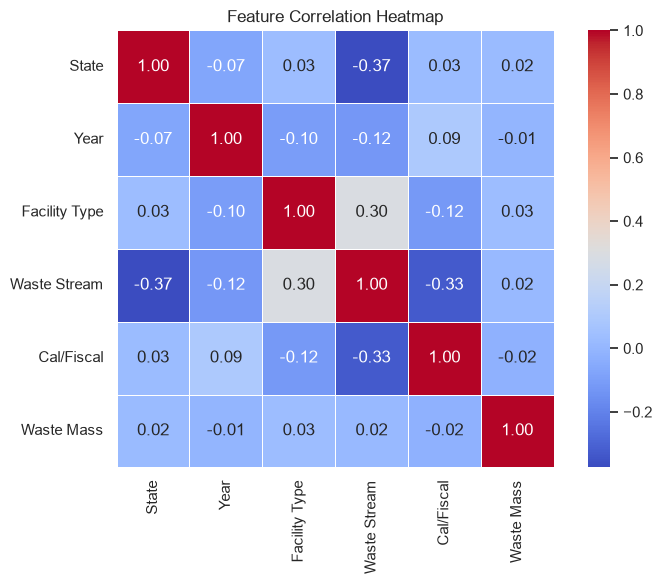

In [80]:
num_cols = ['State_enc', 'Year',
            'ORD-Designated Facility Type_enc',
            'ORD-Designated Waste Stream_enc',
            'Calendar or Fiscal_enc',
            'Waste Mass (short tons)']

corr = df_model[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True,
            xticklabels=['State', 'Year', 'Facility Type', 'Waste Stream', 'Cal/Fiscal', 'Waste Mass'],
            yticklabels=['State', 'Year', 'Facility Type', 'Waste Stream', 'Cal/Fiscal', 'Waste Mass'])
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


Target skewness (raw):  34.35
Target skewness (log):  -0.47

Aggregated dataset: 716 state-year samples  |  39 states
Year range: 1941 – 2023


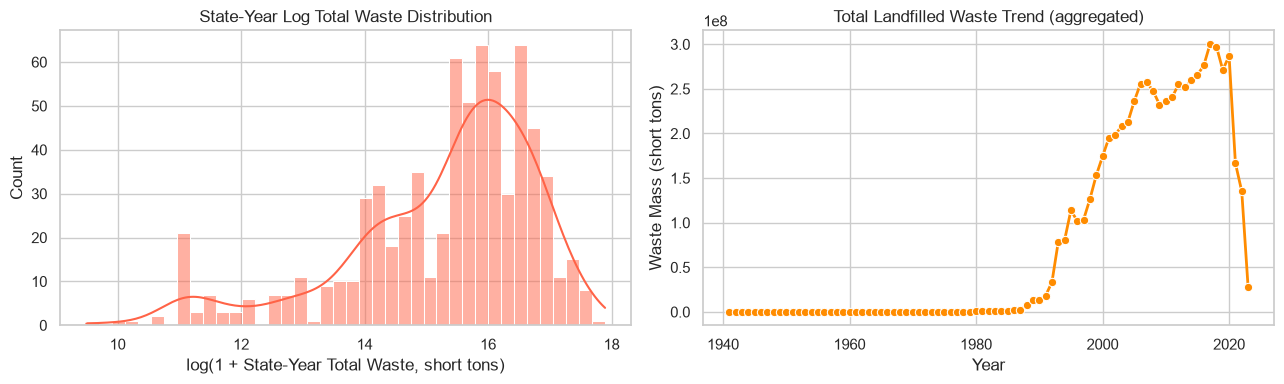

In [81]:
print(f"Target skewness (raw):  {df_model['Waste Mass (short tons)'].skew():.2f}")

# Cap extreme outliers at 99.9th percentile
cap_val = df_model['Waste Mass (short tons)'].quantile(0.999)
df_model['Waste Mass (short tons)'] = df_model['Waste Mass (short tons)'].clip(upper=cap_val)
df_model['log_waste_mass'] = np.log1p(df_model['Waste Mass (short tons)'])
print(f"Target skewness (log):  {df_model['log_waste_mass'].skew():.2f}")

# Aggregate to state-year totals — same resolution as LSTM, removes within-facility noise
df_agg = (df_model
          .groupby(['State_enc', 'Year'])['Waste Mass (short tons)']
          .sum()
          .reset_index()
          .sort_values(['State_enc', 'Year'])
          .reset_index(drop=True))

df_agg['log_total'] = np.log1p(df_agg['Waste Mass (short tons)'])

# Lag and rolling features give tree models explicit temporal signal
grp = df_agg.groupby('State_enc')['log_total']
df_agg['lag1']      = grp.shift(1)
df_agg['lag2']      = grp.shift(2)
df_agg['lag3']      = grp.shift(3)
df_agg['roll3']     = grp.shift(1).rolling(3, min_periods=2).mean().reset_index(level=0, drop=True)
df_agg['yrs_since'] = df_agg.groupby('State_enc')['Year'].transform(lambda x: x - x.min())
df_agg = df_agg.dropna().reset_index(drop=True)

print(f"\nAggregated dataset: {len(df_agg):,} state-year samples  |  {df_agg['State_enc'].nunique()} states")
print(f"Year range: {df_agg['Year'].min()} – {df_agg['Year'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_agg['log_total'], bins=40, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('State-Year Log Total Waste Distribution')
axes[0].set_xlabel('log(1 + State-Year Total Waste, short tons)')
yearly_agg = df_agg.groupby('Year')['Waste Mass (short tons)'].sum().reset_index()
sns.lineplot(data=yearly_agg, x='Year', y='Waste Mass (short tons)',
             ax=axes[1], color='darkorange', marker='o', linewidth=2)
axes[1].set_title('Total Landfilled Waste Trend (aggregated)')
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()


In [82]:
# Build feature matrix from state-year aggregates with lag features
X_COLS = ['State_enc', 'Year', 'yrs_since', 'lag1', 'lag2', 'lag3', 'roll3']
TARGET     = 'log_total'
TARGET_RAW = 'Waste Mass (short tons)'

X = df_agg[X_COLS].values.astype(np.float32)
y = df_agg[TARGET].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_test_orig  = np.expm1(y_test)
y_train_orig = np.expm1(y_train)

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

print(f"Train samples: {X_train_s.shape[0]:,}")
print(f"Test  samples: {X_test_s.shape[0]:,}")
print(f"Features: {X_COLS}")


Train samples: 572
Test  samples: 144
Features: ['State_enc', 'Year', 'yrs_since', 'lag1', 'lag2', 'lag3', 'roll3']


In [83]:
# Helper that prints and returns RMSE, MAE, and R2 for any model prediction
def evaluate_model(y_true, y_pred, name):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"[{name}]  RMSE: {rmse:>15,.2f}  MAE: {mae:>15,.2f}  R2: {r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

all_metrics = []

In [84]:
# Model 1: Linear Regression as a linear baseline for the forecasting task
lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train_s, y_train_s)

y_pred_lr_s = lr_model.predict(X_test_s)
y_pred_lr   = np.expm1(scaler_y.inverse_transform(y_pred_lr_s.reshape(-1, 1)).ravel())

m_lr = evaluate_model(y_test_orig, y_pred_lr, 'Linear Regression')
all_metrics.append(m_lr)

[Linear Regression]  RMSE:    1,052,805.88  MAE:      575,628.12  R2: 0.9861


In [85]:
# Model 2: Random Forest Regressor with 200 trees for non-linear feature interaction
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=20,
    min_samples_leaf=5, n_jobs=-1, random_state=42
)
rf_model.fit(X_train_s, y_train)
y_pred_rf = np.expm1(rf_model.predict(X_test_s))

m_rf = evaluate_model(y_test_orig, y_pred_rf, 'Random Forest')
all_metrics.append(m_rf)

[Random Forest]  RMSE:    1,287,503.12  MAE:      703,021.58  R2: 0.9792


In [86]:
# Model 3: XGBoost Regressor using GPU-accelerated histogram-based boosting
xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    device=xgb_device,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_s, y_train, eval_set=[(X_test_s, y_test)], verbose=False)
y_pred_xgb = np.expm1(xgb_model.predict(X_test_s))

m_xgb = evaluate_model(y_test_orig, y_pred_xgb, 'XGBoost')
all_metrics.append(m_xgb)

[XGBoost]  RMSE:    1,413,426.38  MAE:      785,370.94  R2: 0.9750


In [87]:
# Model 4: Sklearn Gradient Boosting Regressor as a second boosting comparison point
gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    min_samples_leaf=10, random_state=42
)
gb_model.fit(X_train_s, y_train)
y_pred_gb = np.expm1(gb_model.predict(X_test_s))

m_gb = evaluate_model(y_test_orig, y_pred_gb, 'Gradient Boosting')
all_metrics.append(m_gb)

[Gradient Boosting]  RMSE:    1,292,575.57  MAE:      754,780.84  R2: 0.9791


In [88]:
# Aggregate to state-year time series and build sliding-window sequences for LSTM
SEQ_LEN = 3

ts_df = (df_model
         .groupby(['State_enc', 'Year'])['Waste Mass (short tons)']
         .sum()
         .reset_index()
         .sort_values(['State_enc', 'Year']))

X_seq, y_seq = [], []
for sid in ts_df['State_enc'].unique():
    vals = ts_df[ts_df['State_enc'] == sid]['Waste Mass (short tons)'].values
    if len(vals) > SEQ_LEN:
        for i in range(len(vals) - SEQ_LEN):
            X_seq.append(vals[i: i + SEQ_LEN])
            y_seq.append(vals[i + SEQ_LEN])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)

sc_Xl = StandardScaler()
sc_yl = StandardScaler()
X_seq_s = sc_Xl.fit_transform(X_seq)
y_seq_s  = sc_yl.fit_transform(y_seq.reshape(-1, 1)).ravel()

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_seq_s, y_seq_s, test_size=0.2, random_state=42
)
yl_test_orig = sc_yl.inverse_transform(yl_test.reshape(-1, 1)).ravel()

Xl_train_t = torch.FloatTensor(Xl_train).unsqueeze(-1).to(device)
yl_train_t = torch.FloatTensor(yl_train).unsqueeze(-1).to(device)
Xl_test_t  = torch.FloatTensor(Xl_test).unsqueeze(-1).to(device)

train_ds     = TensorDataset(Xl_train_t, yl_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

print(f"LSTM sequences: train={Xl_train.shape}  test={Xl_test.shape}")

LSTM sequences: train=(572, 3)  test=(144, 3)


In [89]:
# Two-layer LSTM with dropout and a dense head for single-step waste-mass forecasting
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size) -> use last hidden state for prediction
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

lstm_model = LSTMForecaster(input_size=1, hidden_size=128, num_layers=2).to(device)
print(lstm_model)
n_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

LSTMForecaster(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable parameters: 207,489


In [90]:
# Train LSTM with Adam, ReduceLROnPlateau scheduler, gradient clipping, and checkpoint saving
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

EPOCHS = 150
best_train_loss = float('inf')
best_lstm_state = None
train_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = lstm_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    train_losses.append(avg)
    scheduler.step(avg)
    if avg < best_train_loss:
        best_train_loss = avg
        best_lstm_state = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch + 1:>3}/{EPOCHS}  Loss: {avg:.6f}")

print(f"Best checkpoint loss: {best_train_loss:.6f}")

Epoch  30/150  Loss: 0.061181
Epoch  60/150  Loss: 0.055041
Epoch  90/150  Loss: 0.052310
Epoch 120/150  Loss: 0.054967
Epoch 150/150  Loss: 0.049096
Best checkpoint loss: 0.045827


In [91]:
# Restore best LSTM checkpoint and evaluate on held-out test sequences
lstm_model.load_state_dict(best_lstm_state)
lstm_model.eval()
with torch.no_grad():
    y_pred_lstm_s = lstm_model(Xl_test_t).cpu().numpy().ravel()

y_pred_lstm = sc_yl.inverse_transform(y_pred_lstm_s.reshape(-1, 1)).ravel()
m_lstm = evaluate_model(yl_test_orig, y_pred_lstm, 'LSTM (PyTorch)')
all_metrics.append(m_lstm)

[LSTM (PyTorch)]  RMSE:    1,901,528.62  MAE:    1,103,570.62  R2: 0.9547


In [92]:
# Deduplicate (guards against re-running model cells), then rank by R2
metrics_df = (pd.DataFrame({m['Model']: m for m in all_metrics}.values())
              .sort_values('R2', ascending=False)
              .reset_index(drop=True))
print("Model Rankings by R2:")
print(metrics_df.to_string(index=False))

best_model_name = metrics_df.iloc[0]['Model']
best_r2         = metrics_df.iloc[0]['R2']
best_rmse       = metrics_df.iloc[0]['RMSE']
print(f"\nBest model: {best_model_name}  R2={best_r2:.4f}  RMSE={best_rmse:,.2f}")


Model Rankings by R2:
            Model         RMSE          MAE       R2
Linear Regression 1.052806e+06 5.756281e+05 0.986124
    Random Forest 1.287503e+06 7.030216e+05 0.979247
Gradient Boosting 1.292576e+06 7.547808e+05 0.979083
          XGBoost 1.413426e+06 7.853709e+05 0.974989
   LSTM (PyTorch) 1.901529e+06 1.103571e+06 0.954733

Best model: Linear Regression  R2=0.9861  RMSE=1,052,805.88


In [93]:
# Bar chart comparing R2 scores of all models with an arrow marking the best model
bar_colors = ['#EF553B' if m == best_model_name else '#636EFA' for m in metrics_df['Model']]

fig_r2 = go.Figure(go.Bar(
    x=metrics_df['Model'],
    y=metrics_df['R2'],
    marker_color=bar_colors,
    text=[f"{v:.4f}" for v in metrics_df['R2']],
    textposition='outside',
    textfont=dict(size=12)
))

fig_r2.add_annotation(
    x=best_model_name,
    y=best_r2,
    ax=0,
    ay=-70,
    xref='x',
    yref='y',
    axref='pixel',
    ayref='pixel',
    text=f"<b>Best Model</b><br>{best_model_name}<br>R2 = {best_r2:.4f}",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowwidth=2.5,
    arrowcolor='#FF0000',
    font=dict(size=12, color='#CC0000', family='Arial'),
    bgcolor='rgba(255,255,255,0.88)',
    bordercolor='#FF0000',
    borderwidth=1.5,
    borderpad=6
)

fig_r2.update_layout(
    title=dict(text='AI Model Comparison: R2 Score on Test Set', font=dict(size=18)),
    xaxis_title='Model',
    yaxis_title='R2 Score (higher is better)',
    yaxis=dict(range=[min(0.0, metrics_df['R2'].min() - 0.1), 1.08]),
    template='plotly_white',
    height=520,
    showlegend=False,
    margin=dict(t=80, b=60)
)
fig_r2.show()

In [94]:
# Bar chart comparing RMSE of all models with an arrow marking the best model
rmse_colors = ['#EF553B' if m == best_model_name else '#00CC96' for m in metrics_df['Model']]

fig_rmse = go.Figure(go.Bar(
    x=metrics_df['Model'],
    y=metrics_df['RMSE'],
    marker_color=rmse_colors,
    text=[f"{v:,.0f}" for v in metrics_df['RMSE']],
    textposition='outside',
    textfont=dict(size=12)
))

fig_rmse.add_annotation(
    x=best_model_name,
    y=best_rmse,
    ax=0,
    ay=-70,
    xref='x',
    yref='y',
    axref='pixel',
    ayref='pixel',
    text=f"<b>Best Model</b><br>{best_model_name}<br>RMSE = {best_rmse:,.0f}",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowwidth=2.5,
    arrowcolor='#AB63FA',
    font=dict(size=12, color='#6A0DAD', family='Arial'),
    bgcolor='rgba(255,255,255,0.88)',
    bordercolor='#AB63FA',
    borderwidth=1.5,
    borderpad=6
)

fig_rmse.update_layout(
    title=dict(text='AI Model Comparison: RMSE on Test Set (lower is better)', font=dict(size=18)),
    xaxis_title='Model',
    yaxis_title='RMSE (short tons)',
    template='plotly_white',
    height=520,
    showlegend=False,
    margin=dict(t=80, b=60)
)
fig_rmse.show()

In [95]:
# Side-by-side subplot of RMSE and MAE for a complete model error comparison
fig_sub = make_subplots(
    rows=1, cols=2,
    subplot_titles=['RMSE by Model', 'MAE by Model']
)

fig_sub.add_trace(
    go.Bar(x=metrics_df['Model'], y=metrics_df['RMSE'],
           marker_color=rmse_colors, name='RMSE',
           text=[f"{v:,.0f}" for v in metrics_df['RMSE']],
           textposition='outside'),
    row=1, col=1
)
fig_sub.add_trace(
    go.Bar(x=metrics_df['Model'], y=metrics_df['MAE'],
           marker_color=['#EF553B' if m == best_model_name else '#FFA15A' for m in metrics_df['Model']],
           name='MAE',
           text=[f"{v:,.0f}" for v in metrics_df['MAE']],
           textposition='outside'),
    row=1, col=2
)

fig_sub.update_layout(
    title=dict(text='Model Error Metrics Comparison', font=dict(size=18)),
    template='plotly_white',
    height=500,
    showlegend=False
)
fig_sub.show()

In [96]:
# Persist the best model, all scalers, encoders, and metrics summary to saved_models directory
SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

sklearn_models = {
    'Linear Regression': lr_model,
    'Random Forest':     rf_model,
    'XGBoost':           xgb_model,
    'Gradient Boosting': gb_model,
}

if best_model_name == 'LSTM (PyTorch)':
    torch.save({
        'model_state_dict': best_lstm_state,
        'arch': {'input_size': 1, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2},
        'scaler_X': sc_Xl,
        'scaler_y': sc_yl,
        'seq_len': SEQ_LEN,
        'metrics': m_lstm
    }, os.path.join(SAVE_DIR, 'best_model_lstm.pth'))
    print(f"Saved LSTM checkpoint to {SAVE_DIR}\\best_model_lstm.pth")
else:
    joblib.dump(sklearn_models[best_model_name],
                os.path.join(SAVE_DIR, 'best_model.joblib'))
    print(f"Saved {best_model_name} to {SAVE_DIR}\\best_model.joblib")

joblib.dump(scaler_X,  os.path.join(SAVE_DIR, 'scaler_X.joblib'))
joblib.dump(scaler_y,  os.path.join(SAVE_DIR, 'scaler_y.joblib'))
joblib.dump(encoders,  os.path.join(SAVE_DIR, 'encoders.joblib'))

with open(os.path.join(SAVE_DIR, 'metrics_summary.json'), 'w') as fh:
    json.dump(metrics_df.to_dict('records'), fh, indent=2)

print("Scalers, encoders, and metrics saved")
print(f"Best model: {best_model_name}  R2={best_r2:.4f}  RMSE={best_rmse:,.2f}")

Saved Linear Regression to saved_models/best_model.joblib
Scalers, encoders, and metrics saved
Best model: Linear Regression  R2=0.9861  RMSE=1,052,805.88
